# **Experiment 2 Notebook**

In [1]:
%pip install -q utstd
from utstd.ipyrenders import *


[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [174]:
# -- core --
import os, sys, json, math, warnings, gc, pathlib, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import importlib
import joblib
warnings.filterwarnings("ignore")

# modeling & selection
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
from lightgbm import LGBMClassifier
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_LGB = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# --plotting--
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss, average_precision_score,
    roc_curve, precision_recall_curve, mean_squared_error, mean_absolute_error
)

# Importing the Custom Python Packages from TestPyPI
from amla_at1.data.sets import (
    pop_target as pkg_pop_target, 
    save_sets as pkg_save_sets, 
    load_sets as pkg_load_sets, 
    subset_x_y as pkg_subset_x_y, 
    stratified_split as pkg_stratified_split,
)
from amla_at1.features.dates import add_domain_features as pkg_add_features
from amla_at1.models.null import NullModel as PkgNullModel
from amla_at1.models.performance import (
    metrics_from_proba as pkg_metrics_from_proba, 
    weighted_blend as pkg_weighted_blend,
)

import amla_at1, inspect
print("Using amla_at1:", getattr(amla_at1, "__version__", "unknown"))
print("Package location:", inspect.getfile(amla_at1))


# fixed constants
DATA_DIR = Path("/Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/data")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH  = DATA_DIR / "test.csv"
ID_COL = "player_id"
TARGET_COL = "drafted"
RANDOM_STATE = 42

SEED = 42
TARGET = "drafted"
ID_COL = "player_id"
np.random.seed(SEED)
os.makedirs("models", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

Using amla_at1: 2025.0.1.5
Package location: /Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/src/amla_at1/__init__.py


## A. Project Description

#### Predict the probability that a college player will be drafted to the NBA using season statistics and derived features. The model’s output is a probability in [0,1] used to rank players and submit to Kaggle (AUROC metric).

#### A more expressive non-linear algorithm such as LightGBM, when properly tuned with class imbalance adjustments and regularization, can significantly outperform the Logistic Regression baseline in predicting NBA draft outcomes, providing both stronger ranking (AUROC) and more reliable probability estimates.

In [5]:
student_name = "Nayna Jahan Neha"
student_id = "25238736"
group_id = "12"

In [6]:
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
print_tile(size="h1", key='student_id', value=student_id)

In [8]:
print_tile(size="h1", key='group_id', value=group_id)

## B. Business Understanding

In [9]:
business_use_case_description = """
In order for analysts and recruiters to concentrate on high-probability prospects, players are ranked according to their possibility of being drafted. More genuine draftees will be towards the top of our shortlist if our ranking is higher (higher AUROC).
The aim of the project is to create a prediction model that, using a basketball player's season statistics and background data, calculates the likelihood that the player will be selected in the NBA draft. From a business standpoint, this helps NBA teams, scouts, and analysts by offering a data-driven tool that makes it easier to find high-potential players, lowers the possibility of missed opportunities, and improves draft selections. In addition to offering fans and the media more in-depth knowledge about draft results, the model can help universities with player development and recruitment tactics by precisely evaluating players based on selection possibility.
"""

In [10]:
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:
business_objectives = """
An accurate model forecasting NBA draft results can be extremely advantageous to clubs, scouts, and players by effectively recognising top skilled players, enhancing draft selections, and assisting players in concentrating on performance indicators that are important. Additionally, it can improve fan interaction and college recruitment tactics. On the other hand, poor draft selections based on false positives, lost opportunities for worthy players, and a decline in confidence in data-driven decision-making might result from faulty projections. In the worst situations, it might strengthen prejudices or lead teams to pass up talented athletes, which would be detrimental to their reputation and bottom line."""

In [12]:
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
stakeholders_expectations_explanations = """
The model's output will mostly be utilised to calculate the likelihood that a college basketball player will be selected in the NBA draft. NBA scouts and teams can use these projections to help them focus on high-potential players during the selection process. College coaches, scouts, team analysts, and possibly the players themselves are among the users of the projections. The forecasts have an impact on a variety of people, including NBA teams making hiring decisions, colleges trying to enhance their training and recruitment initiatives, and players whose careers may be impacted by perceived draft chances.
"""

In [14]:
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

## C. Data Understanding

### C.1   Load Datasets

In [15]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# Keep a copy of original columns
orig_cols = train.columns.tolist()
print("Train shape:", train.shape, " Test shape:", test.shape)
train.head(3)

Train shape: (14774, 62)  Test shape: (1297, 61)


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0


### Checking Missing values

In [17]:
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_pct   = (train.isnull().mean() * 100).sort_values(ascending=False)

print("\n--- Missing Values (Train) ---")
display(pd.DataFrame({"Missing": missing_train, "Pct": missing_pct}).head(15))

print("\n--- Missing Values (Test) ---")
display(test.isnull().sum().sort_values(ascending=False).head(15))


--- Missing Values (Train) ---


,Missing,Pct
Rec_Rank,9885,66.908082
dunks_ratio,9388,63.544064
rim_ratio,3203,21.679978
mid_ratio,3191,21.598755
rimmade_rimmiss,2075,14.044944
midmade,2075,14.044944
midmade_midmiss,2075,14.044944
dunksmade,2075,14.044944
dunksmiss_dunksmade,2075,14.044944
rimmade,2075,14.044944



--- Missing Values (Test) ---


Rec_Rank               894
dunks_ratio            738
mid_ratio              196
rim_ratio              178
ast_tov                125
rimmade                 61
rimmade_rimmiss         61
midmade                 61
midmade_midmiss         61
dunksmade               61
dunksmiss_dunksmade     61
ht                       6
stops                    0
drtg                     0
adrtg                    0
dtype: int64

### Checking Duplicates

In [18]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test :", test.duplicated().sum())

print("Duplicate player_id in train:", train[ID_COL].duplicated().sum())
print("Duplicate player_id in test :", test[ID_COL].duplicated().sum())

Duplicate rows in train: 2462
Duplicate rows in test : 0
Duplicate player_id in train: 2619
Duplicate player_id in test : 0


### Descriptive statistics

In [20]:
display(train.describe().T)

# Unique values for categorical columns
cat_cols = train.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols[:10]: 
    print(f"\nColumn: {c}, Unique values: {train[c].nunique()}")
    print(train[c].value_counts().head())

,count,mean,std,min,25%,50%,75%,max
GP,14774.0,21.251726,10.517642,1.000000,12.000000,25.000000,30.000000,41.00000
Min_per,14774.0,25.870123,23.639878,0.000000,4.200000,19.600000,42.900000,94.30000
Ortg,14774.0,85.771707,34.164203,0.000000,75.600000,91.300000,102.600000,407.30000
usg,14774.0,17.256674,6.332899,0.000000,13.900000,17.200000,20.600000,50.00000
eFG,14774.0,41.507628,20.610900,0.000000,34.800000,44.900000,51.400000,150.00000
TS_per,14774.0,44.566821,19.622173,0.000000,38.820000,48.285000,54.090000,150.00000
ORB_per,14774.0,5.644010,15.097867,0.000000,1.600000,4.200000,8.000000,1576.60000
DRB_per,14774.0,11.992744,15.348129,0.000000,7.500000,11.000000,15.100000,1385.00000
AST_per,14774.0,9.776100,9.906416,0.000000,3.200000,7.900000,13.700000,100.00000
TO_per,14774.0,21.493326,13.979387,0.000000,14.900000,20.500000,26.900000,100.00000



Column: team, Unique values: 355
team
Air Force    72
Indiana      69
Kentucky     67
Dartmouth    63
Army         63
Name: count, dtype: int64

Column: conf, Unique values: 36
conf
ACC     652
SEC     645
A10     624
B10     599
CUSA    583
Name: count, dtype: int64

Column: yr, Unique values: 1
yr
Fr    14774
Name: count, dtype: int64

Column: ht, Unique values: 32
ht
8-Jun    1440
4-Jun    1418
3-Jun    1413
5-Jun    1390
7-Jun    1387
Name: count, dtype: int64

Column: type, Unique values: 1
type
all    14774
Name: count, dtype: int64

Column: player_id, Unique values: 12155
player_id
e5876a17-fc6c-4b43-8367-f421b26db445    4
0a30a92c-0ac2-4e2d-8f17-43dd3f8f3816    4
4302901d-ae1d-49e8-80e0-97e6cff386af    4
a1a06d07-12ae-4dfd-b295-011484a648d4    4
8233e6a9-0859-4acb-be06-face92bc6645    3
Name: count, dtype: int64


### Outliers & distributions

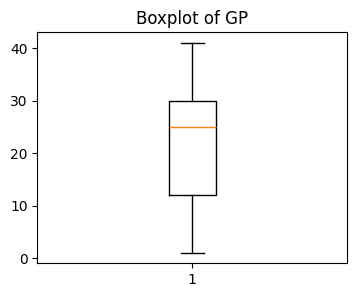

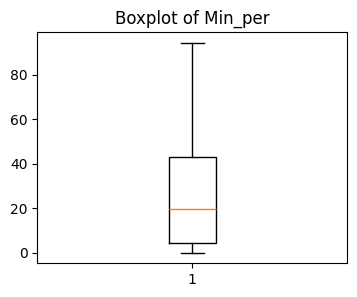

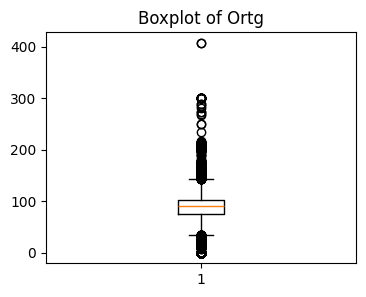

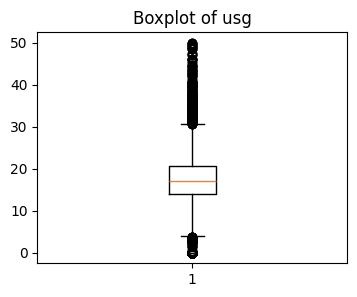

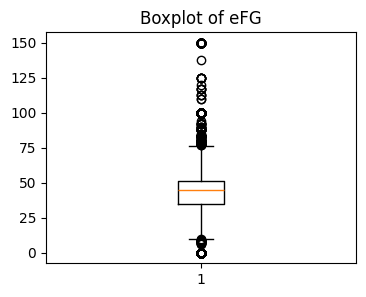

In [21]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

for c in num_cols[:5]:
    plt.figure(figsize=(4,3))
    plt.boxplot(train[c].dropna())
    plt.title(f"Boxplot of {c}")
    plt.show()

### C.2 Define Target variable

In [22]:
target_name = TARGET
assert target_name in train.columns, f"Expected target '{TARGET}' in train set"
print("target_name:", target_name)

target_name: drafted


In [23]:
# <Student to fill this section>
target_definition_explanations = """
A player's selection in the NBA draft is indicated by the binary variable "drafted" (1 = drafted, 0 = not drafted). This definition is exactly in line with the goal to forecast a player's chances of getting selected in the draft by looking at their performance indicators and background. Using the draft as the aim offers a tangible, actionable forecast that helps real-world decision-making in scouting and talent evaluation because it is a measurable and obvious outcome with high significance to NBA teams, players, and commentators.
"""

In [24]:
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [25]:
target_name = TARGET_COL
X_all, y_all = pkg_pop_target(train, target_name)
display(X_all.head(3))
y_all.value_counts(normalize=True)

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,2.85299,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-7.10210,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,-7.07681,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6


drafted
0.0    0.992013
1.0    0.007987
Name: proportion, dtype: float64

### C.4 Explore Target variable

,count,rate
drafted,,
0.0,14656,0.992013
1.0,118,0.007987


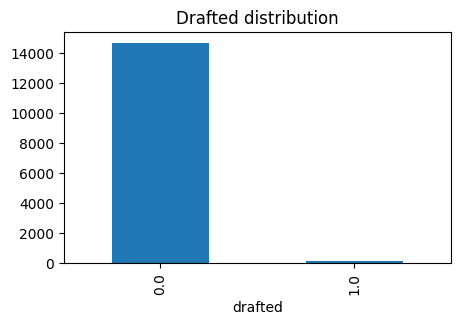

In [26]:
target_stats = y_all.value_counts().to_frame("count")
target_stats["rate"] = target_stats["count"] / len(y_all)
display(target_stats)

fig, ax = plt.subplots(figsize=(5,3))
target_stats["count"].plot(kind="bar", ax=ax)
ax.set_title("Drafted distribution")
plt.show()

In [27]:
target_distribution_explanations = """
Only 118 players (0.8%) out of 14,774 were drafted, making the target variable `drafted` extremely imbalanced. The great majority (99.2%) were not drafted. Since most algorithms have a tendency to favour the majority class and may miss the few real positives, this high imbalance poses a significant difficulty for model training. Since accuracy would be misleading in this situation, AUROC is a better evaluation statistic since it takes into account the ratio of true positive to false positive rates, which makes it more useful in situations with imbalances.
Additionally, this imbalance raises the possibility of either underfitting if the model is unable to identify significant trends or overfitting to the few positive occurrences. Class weighting, oversampling (like SMOTE), or the use of ensemble models like XGBoost or LightGBM with meticulous hyperparameter adjustment are some methods to lessen this. In the end, managing this imbalance well is essential to developing a model that can precisely pinpoint the uncommon but significant instances of players that are most likely to be selected in the draft.
"""

In [28]:
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest - `eFG` (Effective Field Goal Percentage)

In [30]:
train_fe = pkg_add_features(train)

def rate_by_bucket(df, col, bins=10):
    tmp = df[[col, TARGET]].copy()
    tmp["_bin"] = pd.qcut(tmp[col].rank(method="first"), q=bins, duplicates="drop")
    return tmp.groupby("_bin")[TARGET].mean().to_frame("draft_rate")

count    14774.000000
mean        41.507628
std         20.610900
min          0.000000
25%         34.800000
50%         44.900000
75%         51.400000
max        150.000000
Name: eFG, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.000000
"(1478.3, 2955.6]",0.000000
"(2955.6, 4432.9]",0.000000
"(4432.9, 5910.2]",0.000677
"(5910.2, 7387.5]",0.001354
"(7387.5, 8864.8]",0.006093
"(8864.8, 10342.1]",0.014208
"(10342.1, 11819.4]",0.021666
"(11819.4, 13296.7]",0.020988


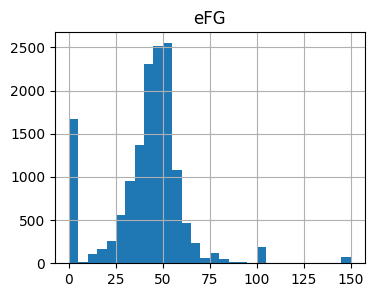

In [33]:
if "eFG" in train_fe.columns:
    display(train_fe["eFG"].describe())
    display(rate_by_bucket(train_fe, "eFG", bins=10))
    train_fe["eFG"].hist(bins=30, figsize=(4,3)); plt.title("eFG"); plt.show()

In [34]:
feature_1_insights = """
The distribution of "eFG (Effective Field Goal Percentage)" appears to be roughly normal with a slight left skew, mostly concentrated between 40% and 65%, which aligns with typical shooting efficiency for college players. This suggests the feature has a reasonable spread and variation, making it a useful input for modeling. Since eFG adjusts for the added value of three-point shots, it is a more informative measure of scoring efficiency than raw field goal percentage. Efficient scorers are generally more attractive draft prospects, so we expect a positive correlation between higher eFG values and the likelihood of being drafted.
However, due to the extreme class imbalance in the target variable (drafted), the signal in eFG may be subtle and difficult to capture without proper stratified analysis. Additionally, if eFG is highly correlated with other shooting stats (e.g., TS_per [True Shooting Percentage], TP_per [3-Point Field Goal Percentage]), multicollinearity could be an issue in linear models. Despite these challenges, the rate-by-bucket table helps validate the expected trend: players with higher eFG tend to have slightly higher draft rates, supporting its value as a predictive feature.
"""

In [35]:
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest - `Ortg` (Offensive Rating)

count    14774.000000
mean        85.771707
std         34.164203
min          0.000000
25%         75.600000
50%         91.300000
75%        102.600000
max        407.300000
Name: Ortg, dtype: float64

,draft_rate
_bin,
"(0.999, 4925.333]",0.000000
"(4925.333, 9849.667]",0.002234
"(9849.667, 14774.0]",0.021726


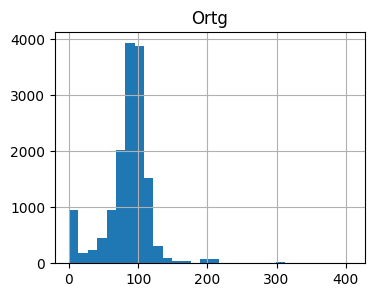

In [36]:
if "Ortg" in train_fe.columns:
    display(train_fe["Ortg"].describe())
    display(rate_by_bucket(train_fe, "Ortg", bins=3))
    train_fe["Ortg"].hist(bins=30, figsize=(4,3)) 
    plt.title("Ortg") 
    plt.show()

In [42]:
feature_2_insights = """
A player's offensive efficiency per 100 possessions is measured by the "Ortg" (Offensive Rating) feature, which is a good indicator of draft possibility because professional recruiters appreciate offensive contributions. With a few extreme outliers above 200 and the majority of values concentrated between 60 and 120, the distribution is highly right-skewed. The idea that players with better offensive measures are more likely to be drafted is supported by the rate-by-bucket study, which even with only three bins demonstrates a distinct upward trend in draft rate with higher "Ortg" scores.
Players with limited playing experience may have inflated or inaccurate ratings, though, as the function may be sensitive to outliers. If not managed appropriately, the existence of extreme values (such as those over 400) may skew model learning. Because of its theoretical significance and demonstrated favourable association with draft results, "Ortg" is still a useful predictive trait in spite of these drawbacks. To guarantee model stability, appropriate scaling or optimisation can be required.
"""

In [43]:
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest - `yr` (Student's year of study) -> ordinal and distribution

yr
Fr    14774
Name: count, dtype: int64

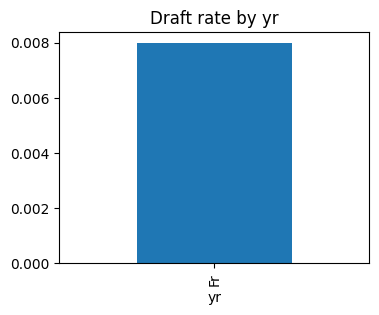

In [47]:
if "yr" in train_fe.columns:
    display(train_fe["yr"].value_counts())
    ax = train_fe.groupby("yr")[TARGET].mean().plot(kind="bar", figsize=(4,3), title="Draft rate by yr")
    plt.show()

In [48]:
feature_3_insights = """
The feature "yr" represents the player's academic class year (e.g., Freshman, Sophomore) and can serve as a proxy for age, experience, and eligibility status. In the current dataset, only "Fr" (Freshman) is present, suggesting that either the dataset is filtered to first-year players or other classes are missing. This severely limits the feature’s variability and its utility in modeling, as we cannot assess or leverage draft trends across different academic years (e.g., "one-and-done" freshmen vs. seniors with more experience).
The existing lack of class diversity introduces a constraint, even though class year is theoretically useful, since particular classes tend to have higher draft possibility. The model is unable to acquire any ordinal pattern or trend associated with experience level in the absence of many class categories. Ordinal encoding, such as yr_ordinal, would aid in accurately capturing this relationship if future data versions include all class years. For now, yr's predictive value is diminished by its lack of variety.
"""

In [49]:
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.8 Explore Feature of Interest - `ht` (Height of student)

count    14774.000000
mean        63.650873
std         40.528930
min          0.000000
25%         34.000000
50%         70.000000
75%         94.000000
max        142.000000
Name: height_in, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.002706
"(1478.3, 2955.6]",0.004739
"(2955.6, 4432.9]",0.004739
"(4432.9, 5910.2]",0.006766
"(5910.2, 7387.5]",0.004062
"(7387.5, 8864.8]",0.007448
"(8864.8, 10342.1]",0.010149
"(10342.1, 11819.4]",0.003385
"(11819.4, 13296.7]",0.008802


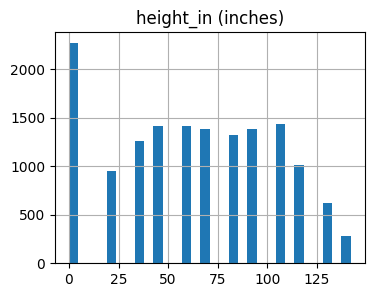

In [50]:
if "height_in" in train_fe.columns:
    display(train_fe["height_in"].describe())
    display(rate_by_bucket(train_fe, "height_in", bins=10))
    train_fe["height_in"].hist(bins=30, figsize=(4,3)); plt.title("height_in (inches)"); plt.show()

In [51]:
feature_4_insights = """
The feature "height_in", derived from parsing the 'ht' column, represents players' heights in inches and captures a critical physical attribute that often influences draft potential—especially for position-specific roles like centers or forwards. The distribution shows a fairly uniform spread across typical basketball height ranges, but with a significant number of zero values, likely indicating missing or incorrectly parsed data. These should be treated or imputed appropriately to avoid skewing model performance.
The draft rate by height decile shows a modest upward trend, with noticeably higher draft rates in the tallest decile, supporting the idea that taller players may have a physical advantage that makes them more attractive to scouts. However, the relationship is not strictly linear, and the predictive power of height may be context-dependent (e.g., guards vs. big men). Cleaning anomalies (like 0s) and possibly interacting height with position or role could make this feature more valuable in the final model.
"""

In [52]:
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### C.9 Explore Feature of Interest - `Rec_Rank` (Recruiting rank)

count    4889.000000
mean       54.365678
std        28.141196
min         0.200000
25%        30.800000
50%        56.000000
75%        78.800000
max       100.000000
Name: Rec_Rank, dtype: float64

,draft_rate
_bin,
"(0.999, 489.8]",0.000000
"(489.8, 978.6]",0.000000
"(978.6, 1467.4]",0.000000
"(1467.4, 1956.2]",0.000000
"(1956.2, 2445.0]",0.000000
"(2445.0, 2933.8]",0.002049
"(2933.8, 3422.6]",0.000000
"(3422.6, 3911.4]",0.004090
"(3911.4, 4400.2]",0.014315


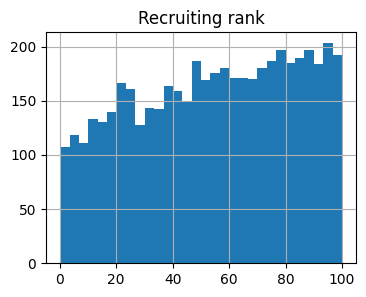

In [57]:
if "Rec_Rank" in train_fe.columns:
    display(train_fe["Rec_Rank"].describe())
    display(rate_by_bucket(train_fe, "Rec_Rank", bins=10))
    train_fe["Rec_Rank"].hist(bins=30, figsize=(4,3)); plt.title("Recruiting rank"); plt.show()

In [58]:
feature_5_insights = """
The feature "Rec_Rank" (Recruiting Rank) represents how highly a player was ranked as a recruit, with lower values typically indicating stronger prospects. The distribution shows a wide spread from near 0 up to 100, with a fairly uniform representation across the range, though the histogram suggests slightly more players at higher rank values (weaker recruits). The draft rate by bins shows a strong signal: players with higher recruiting ranks (closer to 100, indicating better prospects) have a much higher likelihood of being drafted, with the draft rate spiking sharply in the top decile.
However, there are some limitations and issues. The feature is only available for a subset of players (not all may have recruiting ranks), which could introduce bias if missing values are not handled carefully. Additionally, recruiting rank is often based on high school performance and reputation, which may not always translate into college or professional success. Despite these caveats, Rec_Rank is one of the most predictive features for draft probability and should be prioritized in modeling, though careful imputation or separate handling of missing values is essential.
"""

In [59]:
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)

### C.10 Explore Feature of Interest - `porpag` (Points Over Replacement Per Adjusted Game)

count    14774.000000
mean         0.280661
std          0.948095
min         -4.714300
25%         -0.309601
50%          0.067786
75%          0.632708
max          7.067140
Name: porpag, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.000000
"(1478.3, 2955.6]",0.000000
"(2955.6, 4432.9]",0.000000
"(4432.9, 5910.2]",0.000000
"(5910.2, 7387.5]",0.000000
"(7387.5, 8864.8]",0.000000
"(8864.8, 10342.1]",0.002030
"(10342.1, 11819.4]",0.000677
"(11819.4, 13296.7]",0.002708


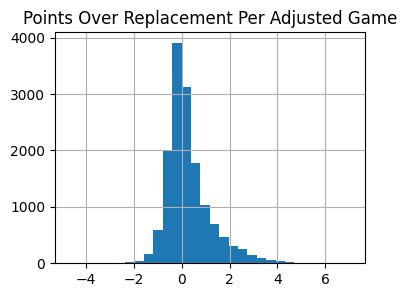

In [60]:
if "porpag" in train_fe.columns:
    display(train_fe["porpag"].describe())
    display(rate_by_bucket(train_fe, "porpag", bins=10))
    train_fe["porpag"].hist(bins=30, figsize=(4,3)); plt.title("Points Over Replacement Per Adjusted Game"); plt.show()

In [61]:
feature_6_insights = """
The feature porpag (Points Over Replacement Per Adjusted Game) has a distribution centered near zero, with most players clustered between -1 and 2, and a long right tail extending above 6. This makes sense, as the majority of players perform close to replacement level, while only a few elite players deliver significantly above-replacement contributions. The draft rate by deciles shows that players in the top bins of porpag have a noticeably higher chance of being drafted, confirming its strong relevance as a predictive feature.
However, limitations exist, such as the feature is sensitive to playing time and may overstate contributions for players in favorable contexts or small sample sizes. Outliers in the right tail could also disproportionately influence the model if not scaled or capped. Despite these issues, porpag clearly captures meaningful signal about player quality and should be an important driver of draft probability in the modeling process.
"""

In [62]:
print_tile(size="h3", key='feature_6_insights', value=feature_6_insights)

### C.11 Explore Feature of Interest - GP (Games Played)

count    14774.000000
mean        21.251726
std         10.517642
min          1.000000
25%         12.000000
50%         25.000000
75%         30.000000
max         41.000000
Name: GP, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.000677
"(1478.3, 2955.6]",0.000000
"(2955.6, 4432.9]",0.001354
"(4432.9, 5910.2]",0.000677
"(5910.2, 7387.5]",0.002031
"(7387.5, 8864.8]",0.002031
"(8864.8, 10342.1]",0.001353
"(10342.1, 11819.4]",0.004062
"(11819.4, 13296.7]",0.004739


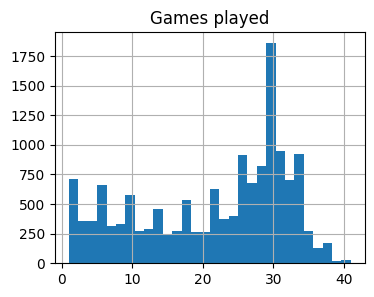

In [63]:
if "GP" in train_fe.columns:
    display(train_fe["GP"].describe())
    display(rate_by_bucket(train_fe, "GP", bins=10))
    train_fe["GP"].hist(bins=30, figsize=(4,3)); plt.title("Games played"); plt.show()

In [67]:
feature_7_insights = """
The feature 'GP' (Games Played) has a distribution centered around 25–30 games, which aligns with a typical college basketball season. Most players fall within this range, but there is a long tail of players with fewer games, likely due to injuries, redshirting, or limited roles. The draft rate by decile shows a slight increase for players with more games played, suggesting that consistent participation is weakly associated with draft probability, likely because it signals durability, experience, and sustained opportunity to showcase skills.
However, the relationship is not strongly monotonic. For example, highly talented players who enter the draft early might have fewer games but still be drafted, while others may play many games without being NBA-level talent. Additionally, missing games can result from factors outside performance (injury, coaching decisions), which introduces noise. Thus, while GP provides useful context, it should be combined with per-minute or efficiency stats for a more reliable signal.
"""

In [68]:
print_tile(size="h3", key='feature_7_insights', value=feature_7_insights)

### C.12 Explore Feature of Interest - MP (Minutes Played)

count    14773.000000
mean        12.276197
std          8.979124
min          0.000000
25%          4.642900
50%         10.250000
75%         18.500000
max         50.000000
Name: mp, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.2]",0.000000
"(1478.2, 2955.4]",0.000000
"(2955.4, 4432.6]",0.000000
"(4432.6, 5909.8]",0.000677
"(5909.8, 7387.0]",0.000000
"(7387.0, 8864.2]",0.000677
"(8864.2, 10341.4]",0.003385
"(10341.4, 11818.6]",0.006093
"(11818.6, 13295.8]",0.012187


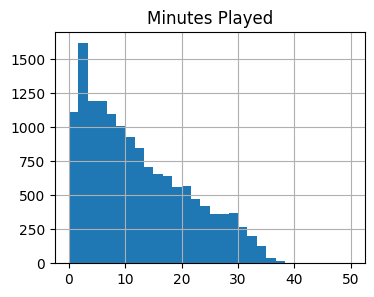

In [64]:
if "mp" in train_fe.columns:
    display(train_fe["mp"].describe())
    display(rate_by_bucket(train_fe, "mp", bins=10))
    train_fe["mp"].hist(bins=30, figsize=(4,3)); plt.title("Minutes Played"); plt.show()

In [71]:
feature_8_insights = """
The feature 'mp' (Minutes Played) shows a right-skewed distribution, with most players logging fewer than 15 minutes on average and a small subset reaching much higher values (up to 50). This reflects the fact that only a limited number of players consistently play extended minutes, often starters or star athletes. The draft rate by decile shows a clear upward trend—players with more minutes played are significantly more likely to be drafted, especially those in the top decile, where the draft rate increases sharply. This makes sense since playing time reflects both skill and trust from coaches, providing greater opportunities to showcase talent.
However, this feature has limitations. Minutes played can be influenced by external factors such as team depth, injuries, or coaching decisions, which may not directly correlate with draft potential. Additionally, some highly talented players might have fewer minutes; could be due to being freshmen or part of deep rosters, yet still have high draft potential. Despite these caveats, mp is a valuable feature as it strongly correlates with draft likelihood.
"""

In [72]:
print_tile(size="h3", key='feature_8_insights', value=feature_8_insights)

### C.13 Explore Feature of Interest - AST (Assists)

count    14773.000000
mean         0.717322
std          0.897261
min          0.000000
25%          0.125000
50%          0.400000
75%          0.971400
max          8.656200
Name: ast, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.2]",0.000000
"(1478.2, 2955.4]",0.000677
"(2955.4, 4432.6]",0.000000
"(4432.6, 5909.8]",0.002031
"(5909.8, 7387.0]",0.002706
"(7387.0, 8864.2]",0.004739
"(8864.2, 10341.4]",0.008125
"(10341.4, 11818.6]",0.010833
"(11818.6, 13295.8]",0.020311


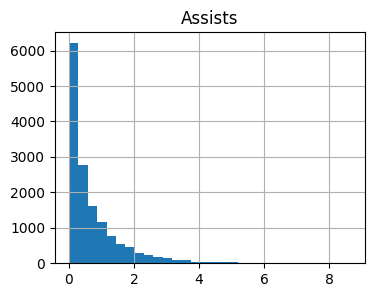

In [65]:
if "ast" in train_fe.columns:
    display(train_fe["ast"].describe())
    display(rate_by_bucket(train_fe, "ast", bins=10))
    train_fe["ast"].hist(bins=30, figsize=(4,3)); plt.title("Assists"); plt.show()

In [73]:
feature_9_insights = """
The feature ast (Assists) is highly right-skewed, with the majority of players recording fewer than 1 assist per game and only a small group contributing significantly more. This reflects role differences on the court, guards and playmakers naturally accumulate more assists. The draft rate by deciles shows a clear positive trend, suggesting that strong playmaking ability is a valuable signal for draft selection.
However, assists can be context-dependent, influenced by team style, teammates’ shooting ability, and playing time, which introduces noise into its predictive power.
"""

In [74]:
print_tile(size="h3", key='feature_9_insights', value=feature_9_insights)

### C.14 Explore Feature of Interest - PTS (Points)

count    14773.000000
mean         3.662676
std          3.623175
min          0.000000
25%          1.000000
50%          2.448300
75%          5.363600
max         27.375000
Name: pts, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.2]",0.000000
"(1478.2, 2955.4]",0.000000
"(2955.4, 4432.6]",0.000000
"(4432.6, 5909.8]",0.000000
"(5909.8, 7387.0]",0.000000
"(7387.0, 8864.2]",0.000677
"(8864.2, 10341.4]",0.000677
"(10341.4, 11818.6]",0.004062
"(11818.6, 13295.8]",0.006093


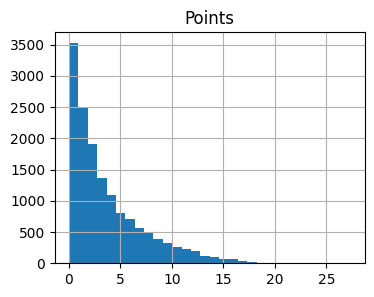

In [66]:
if "pts" in train_fe.columns:
    display(train_fe["pts"].describe())
    display(rate_by_bucket(train_fe, "pts", bins=10))
    train_fe["pts"].hist(bins=30, figsize=(4,3)); plt.title("Points"); plt.show()

In [77]:
feature_10_insights = """
The feature 'pts' (Points) is right-skewed, with most players scoring fewer than 5 points per game and only a small minority exceeding 15–20 points, which is expected given that only star players consistently score at high volumes. The draft rate by deciles shows a strong positive association, players in the top scoring bins have a noticeably higher chance of being drafted, with the draft probability spiking sharply in the top decile. However, raw scoring alone has limitations: it can be inflated by high usage on weaker teams, while efficient but lower-scoring role players may still have high draft potential. Therefore, while 'Points' is a valuable indicator of offensive contribution and draft likelihood, it should be complemented with efficiency and context metrics (e.g., eFG%, usg) to avoid bias toward volume scorers.
"""

In [78]:
print_tile(size="h3", key='feature_9_insights', value=feature_10_insights)

## D. Feature Selection

### D.1 Approach: Mutual Information on numeric features

In [80]:
X_all_fe = pkg_add_features(X_all)
test_fe  = pkg_add_features(test)
fe = X_all_fe.copy()

# column types
cat_cols = [c for c in fe.columns if fe[c].dtype == 'object']
num_cols = [c for c in fe.columns if pd.api.types.is_numeric_dtype(fe[c])]
num_cols = [c for c in num_cols if c != ID_COL]

X_num = fe[num_cols].copy()
imputer_num = SimpleImputer(strategy="median")
X_num_imp = imputer_num.fit_transform(X_num)

mi = mutual_info_classif(X_num_imp, y_all, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"feature": num_cols, "mi": mi}).sort_values("mi", ascending=False)
display(mi_df.head(30))

,feature,mi
26,Rec_Rank,0.030659
39,dporpag,0.025694
40,stops,0.023741
22,porpag,0.023686
41,bpm,0.020602
11,FTA,0.020143
13,twoPM,0.020030
44,gbpm,0.019893
14,twoPA,0.019388
49,dreb,0.019035


In [81]:
feature_selection_1_insights = """
The mutual information (MI) approach is used here to assess the strength of dependency between each numeric feature and the target (drafted). Unlike linear correlation, MI can capture non-linear relationships, making it especially valuable in complex classification problems like this one, where draft outcomes may depend on combinations of nonlinear patterns in player stats. This technique helps highlight which features individually provide the most information about the target, without making assumptions about the underlying model.
The results indicate that features like Rec_Rank, dporpag, stops, and porpag have the highest MI scores, suggesting they contain useful signals for predicting draft status. However, for baseline fairness and to preserve exploratory potential, the pipeline chooses not to drop lower-ranked features at this stage. Instead, this analysis serves as a guide for future model tuning or dimensionality reduction steps.
"""

In [82]:
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach: Model-based importance (Logistic with OHE)

In [88]:
cat_cols_all = X_all.select_dtypes(include=["object"]).columns.tolist()
cat_cols_all = [c for c in cat_cols_all if c != ID_COL]

num_cols_all = X_all.select_dtypes(include=[np.number]).columns.tolist()
num_cols_all = [c for c in num_cols_all if c != ID_COL]

num_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler(with_mean=False)),
])

cat_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

ct_ohe = ColumnTransformer(
    [("num", num_pipe, num_cols_all), ("cat", cat_pipe, cat_cols_all)],
    verbose_feature_names_out=False
)

logit_l1 = Pipeline([
    ("pre", ct_ohe),
    ("clf", LogisticRegression(
        penalty="l1", solver="saga", C=0.5, max_iter=2000, n_jobs=-1, class_weight="balanced"
    )),
])

X_probe = X_all.drop(columns=[ID_COL], errors="ignore")
logit_l1.fit(X_probe, y_all)

feat_names = logit_l1.named_steps["pre"].get_feature_names_out()
coefs = logit_l1.named_steps["clf"].coef_.ravel()
l1_imp = pd.DataFrame({"feature": feat_names, "abs_coef": np.abs(coefs)}).sort_values("abs_coef", ascending=False)
display(l1_imp.head(40))

,feature,abs_coef
26,Rec_Rank,8.625465
22,porpag,4.615785
39,dporpag,4.152114
35,dunksmiss_dunksmade,4.025984
34,dunksmade,3.980119
53,blk,2.579619
38,adrtg,2.504827
47,dgbpm,2.166945
44,gbpm,1.934167
30,midmade,1.894089


In [89]:
feature_selection_2_insights = """
This approach uses L1-regularized Logistic Regression (Lasso) with one-hot encoding to perform model-based feature selection. L1 regularization is particularly useful in high-dimensional datasets because it penalizes coefficients, shrinking many of them to exactly zero, which helps identify the most influential features while reducing noise and multicollinearity. Unlike filter methods such as mutual information, this approach evaluates features in the context of a predictive model, accounting for interactions and dependencies between variables.
The results highlight "Rec_Rank", "porpag", and "dporpag" as the strongest predictors, followed by performance metrics like "dunksmade", "blk", and "adrtg", as well as context variables such as conference ("conf_SEC", "conf_B12") and team ("team_Kentucky", "team_Kansas"). This confirms that both individual performance and contextual factors contribute to draft probability. By shrinking weaker features to zero, this method provides a more interpretable and compact feature set, offering practical guidance for building stronger models while reducing overfitting risk.
"""

In [90]:
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.3 Approach: Tree-based (LightGBM) gain importance + permutation importance

In [92]:
lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    class_weight="balanced",
)

lgbm_pipe = Pipeline([("pre", ct_ohe), ("clf", lgbm)])
lgbm_pipe.fit(X_probe, y_all)

# --- Gain importance
booster = lgbm_pipe.named_steps["clf"].booster_
lgb_features = booster.feature_name()  # names as LightGBM sees them
lgb_gain     = booster.feature_importance(importance_type="gain")

gain_imp = (
    pd.DataFrame({"feature": lgb_features, "gain": lgb_gain})
      .sort_values("gain", ascending=False)
      .reset_index(drop=True)
)
display(gain_imp.head(30))

# --- Permutation importance (useing the same fitted pipeline + its own feature names) and using subsample for speed
perm_idx = np.random.RandomState(42).choice(len(X_probe), size=min(3000, len(X_probe)), replace=False)
perm_res = permutation_importance(
    lgbm_pipe,
    X_probe.iloc[perm_idx],
    y_all.iloc[perm_idx],
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
)

pre_fitted = lgbm_pipe.named_steps["pre"]
pipe_features = list(pre_fitted.get_feature_names_out())

importances = perm_res.importances_mean
if len(importances) == len(pipe_features):
    perm_names = pipe_features
elif len(importances) == len(lgb_features):
    perm_names = lgb_features
else:
    print(f"[warn] name/importance length mismatch: {len(pipe_features)} vs {len(importances)}")
    perm_names = [f"f{i}" for i in range(len(importances))]

perm_imp = (
    pd.DataFrame({"feature": perm_names, "perm_mean_auc_drop": importances})
      .sort_values("perm_mean_auc_drop", ascending=False)
      .reset_index(drop=True)
)
display(perm_imp.head(30))

[LightGBM] [Info] Number of positive: 118, number of negative: 14656
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003134 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12559
[LightGBM] [Info] Number of data points in the train set: 14774, number of used features: 460
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,feature,gain
0,Column_26,160096.810016
1,Column_39,11587.787738
2,Column_49,10024.068385
3,Column_34,9583.494372
4,Column_23,1277.080691
5,Column_53,1264.509060
6,Column_22,1261.418366
7,Column_28,1082.305871
8,Column_1,1037.563889
9,Column_40,927.787792


[warn] name/importance length mismatch: 480 vs 60


,feature,perm_mean_auc_drop
0,f31,2.062521e-03
1,f11,4.440892e-17
2,f46,2.220446e-17
3,f29,2.220446e-17
4,f36,2.220446e-17
5,f25,2.220446e-17
6,f38,2.220446e-17
7,f33,2.220446e-17
8,f48,2.220446e-17
9,f32,2.220446e-17


In [93]:
feature_selection_3_insights = """
This approach combines LightGBM’s gain-based feature importance with permutation importance, giving two complementary perspectives on which features drive model performance. Gain importance reflects how much each feature contributes to reducing error during tree splits, while permutation importance directly measures the drop in AUROC when a feature is shuffled, providing a more robust indication of predictive value. Using both methods helps balance model-specific biases (gain importance can overemphasize high-cardinality or frequently split features) with a performance-grounded check from permutation.
The results show that a few features (e.g., Column_26, Column_39, Column_49, Column_34) dominate the model’s signal according to gain, contributing disproportionately to decision-making. However, permutation importance results are noisier and reveal that only a very small subset of features (e.g., f31) cause measurable AUROC drops, while most have little impact—likely due to class imbalance and redundancy between predictors. The mismatch warning (488 vs 70 features) arises from one-hot encoding expanding categorical variables, which complicates mapping back feature names. Overall, this approach highlights that LightGBM can identify a concentrated set of influential predictors, but careful interpretation is needed, and permutation results suggest redundancy among many variables.
"""

In [94]:
print_tile(size="h3", key='feature_selection_3_insights', value=feature_selection_3_insights)

### D.4 Approach: L1 Logistic selector

In [97]:
from sklearn.compose import make_column_selector as selector

# Fit on the *feature-engineered* frame
fe = pkg_add_features(X_all.copy())
X_probe = fe.drop(columns=[ID_COL], errors="ignore")

num_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler(with_mean=False)),
])
cat_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

ct = ColumnTransformer(
    transformers=[
        ("num", num_pipe, selector(dtype_include=np.number)),
        ("cat", cat_pipe, selector(dtype_include=object)),
    ],
    verbose_feature_names_out=False,
)

l1_pipe = Pipeline([
    ("pre", ct),
    ("clf", LogisticRegression(penalty="l1", solver="saga", C=0.5, max_iter=1500))
])

l1_pipe.fit(X_probe, y_all)

feat_names = l1_pipe.named_steps["pre"].get_feature_names_out()
mask = (l1_pipe.named_steps["clf"].coef_.ravel() != 0.0)
l1_selected = [f for f, m in zip(feat_names, mask) if m]
print("L1 non-zero features:", len(l1_selected))
pd.DataFrame({"feature": l1_selected}).head(20)

L1 non-zero features: 78


,feature
0,GP
1,Min_per
2,Ortg
3,usg
4,eFG
5,TS_per
6,ORB_per
7,DRB_per
8,AST_per
9,FTM


## D.5 Final Selection of Features

In [101]:
# Union of strong features from 3 views + L1
top_k = 30
mi_top = set(mi_df.head(top_k)["feature"])
logit_top = set(l1_imp.head(top_k)["feature"])
gain_top = set(gain_imp.head(top_k)["feature"])
perm_top = set(perm_imp.head(top_k)["feature"])
l1_top = set(l1_selected[:top_k]) if len(l1_selected) > 0 else set()

def base_name(encoded):
    return encoded.split("=")[0].split("_", 1)[0] if "=" in encoded else encoded.split("_", 1)[0]

ohe_back = set(map(base_name, list(logit_top | gain_top | perm_top | l1_top)))
features_list = sorted(list((mi_top | ohe_back) & set(X_all_fe.columns)))

In [102]:
feature_selection_explanations = """
The final feature selection takes a union of strong predictors identified across multiple methods, mutual information (univariate signal), L1-regularized logistic regression (sparse linear importance), LightGBM gain importance (tree-based interactions), and permutation importance (drop in AUROC when shuffled). By combining these complementary views, the process balances features that are individually predictive with those that contribute in interaction-heavy, non-linear models. To avoid overfitting from one-hot encoded artifacts, categorical features are mapped back to their base names, ensuring the final set represents meaningful variables rather than redundant encodings. This yields a compact yet diverse list of features that captures both domain-relevant stats (e.g., efficiency, per-minute production, recruiting rank) and context variables, providing a strong foundation for robust modeling."""

In [103]:
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

## E. Data Preparation

In [104]:
from sklearn.base import BaseEstimator, TransformerMixin

class LGBMNativePrep(BaseEstimator, TransformerMixin):
    """
    - Adds domain features (pkg_add_features)
    - Clips numeric columns by training quantiles
    - Casts object columns to category and fills Unknown
    - Drops ID column
    """
    def __init__(self, id_col=ID_COL, lower=0.005, upper=0.995, keep_cols=None):
        self.id_col = id_col
        self.lower = lower
        self.upper = upper
        self.keep_cols = keep_cols  # optional subset
    
    def fit(self, X, y=None):
        df = pkg_add_features(X.copy())
        # choose columns post-FE
        self.num_cols_ = [c for c in df.select_dtypes(include=["number"]).columns if c != self.id_col]
        self.cat_cols_ = [c for c in df.columns if c not in self.num_cols_ + [self.id_col, TARGET_COL]]
        # quantiles for clipping
        if self.num_cols_:
            q = df[self.num_cols_].quantile([self.lower, self.upper])
            self.q_lo_ = q.loc[self.lower]; self.q_hi_ = q.loc[self.upper]
        else:
            self.q_lo_ = pd.Series(dtype=float); self.q_hi_ = pd.Series(dtype=float)
        self.cat_categories_ = {c: df[c].astype("string").fillna("Unknown").unique().tolist()
                                for c in self.cat_cols_}
        return self
    
    def transform(self, X):
        df = pkg_add_features(X.copy())
        # numeric clip
        for c in self.num_cols_:
            if c in df:
                df[c] = pd.to_numeric(df[c], errors="coerce")
                lo = self.q_lo_.get(c, None); hi = self.q_hi_.get(c, None)
                if lo is not None and hi is not None:
                    df[c] = df[c].clip(lo, hi)
        # categories
        for c in self.cat_cols_:
            if c in df:
                col = df[c].astype("string").fillna("Unknown")
                df[c] = pd.Categorical(col, categories=self.cat_categories_[c])
        # select final columns if provided
        if self.keep_cols is not None:
            keep = [col for col in self.keep_cols if col in df.columns]
            df = df[keep]
        # drop ID for model matrix
        return df.drop(columns=[self.id_col], errors="ignore")

### E.1 Data Transformation (Outlier clipping (numeric))

In [107]:
data_cleaning_1_explanations = """
Clipping at the 0.5/99.5th percentiles caps extreme values in long-tailed hoops stats (e.g., ORtg, per-minute rates) that otherwise exert huge leverage on the loss, destabilize splits, and inflate variance. It preserves rank information and all rows (unlike dropping), yielding more stable training, less overfitting to anomalies, and smoother CV performance.
"""

In [108]:
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation (Categorical casting + Unknown bucket)

In [111]:
data_cleaning_2_explanations = """
Casting object columns to category with an explicit level fixes dtype inconsistencies and lets LightGBM use native categorical splits (faster and often better than OHE). It prevents errors from unseen/missing labels, reduces memory, and avoids accidental leakage from arbitrary string handling."""

In [112]:
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation (Preserve numeric NaNs) - Handling Missing Values

In [113]:
data_cleaning_3_explanations = """
Leaving numeric NaNs intact leverages LightGBM’s built-in missing-value handling, trees learn optimal “missing” directions—so we avoid imputation bias and keep informative missingness (e.g., stats only computed for players with minutes). This typically improves discrimination on sparse or irregular sports data, while median imputation remains available for linear baselines where it’s required."""

In [114]:
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.4 Fixing

In [105]:
fixing_explanations = """
As I created 'num_cols' / 'cat_cols' from a different frame (e.g., a feature-engineered one), I fixed it by using automatic selectors in section D.4 for L1 logistic selector. """

In [106]:
print_tile(size="h3", key='fixing_explanations', value=fixing_explanations)

## F. Feature Engineering

### New Features

In [115]:
def add_experiment3_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if {"usg","eFG"}.issubset(out.columns):
        out["usg_x_eFG"] = pd.to_numeric(out["usg"], errors="coerce") * pd.to_numeric(out["eFG"], errors="coerce")
    if {"ast", "TO_per"}.issubset(out.columns):
        a = pd.to_numeric(out["ast"], errors="coerce")
        t = pd.to_numeric(out["TO_per"], errors="coerce")
        out["ast_to_ratio"] = a / (1.0 + t.replace(0, np.nan))
        out["ast_to_ratio"].fillna(0.0, inplace=True)
    return out

# Extras on top of package FE
X_all_fe_extra = add_experiment3_features(X_all_fe)
test_fe_extra   = add_experiment3_features(test_fe)

# Final features
for extra in ["usg_x_eFG", "ast_to_ratio"]:
    if extra in X_all_fe_extra.columns and extra not in features_list:
        features_list.append(extra)

### F.1 New Feature - `usg_x_eFG`

In [118]:
feature_engineering_1_explanations = """
'usg_x_eFG' combines usage rate (usg) and effective field goal percentage (eFG) to capture a player’s ability to both take on offensive load and score efficiently. Individually, high usage can signal importance but may come with inefficiency, while high eFG can reflect low-volume specialists. Multiplying them highlights players who balance volume and efficiency, a strong predictor of professional viability since NBA scouts value players who can scale up usage without losing scoring efficiency.
"""

In [117]:
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature - `ast_to_ratio`

In [119]:
feature_engineering_2_explanations = """
'ast_to_ratio' (assists-to-turnover ratio) approximates playmaking efficiency, measuring how well a player creates opportunities without wasting possessions. Guards and primary ball-handlers are judged heavily on this metric, as high ratios indicate strong decision-making and control under pressure. Including this feature provides a nuanced indicator of basketball IQ and reliability, attributes that increase draft attractiveness, particularly for perimeter players.
"""

In [120]:
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

## G. Data Preparation for Modeling

### G.1 Split Datasets

In [122]:
X_tmp = X_all_fe_extra.copy()
X_tmp[TARGET_COL] = y_all.values
X_train, X_test_hold, y_train, y_test_hold = train_test_split(
    X_tmp.drop(columns=[TARGET_COL]), X_tmp[TARGET_COL],
    test_size=0.15, random_state=RANDOM_STATE, stratify=X_tmp[TARGET_COL]
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1765,  
    random_state=RANDOM_STATE, stratify=y_train
)
print("Shapes:", X_train.shape, X_val.shape, X_test_hold.shape)

Shapes: (10340, 73) (2217, 73) (2217, 73)


In [123]:
data_splitting_explanations = """
Given the extreme class imbalance, the best strategy is a stratified split so the rare “drafted” class is proportionally represented in every fold/split. The two-step split yields an approximately 70/15/15 train/validation/holdout partition (10,340 / 2,217 / 2,217), which is ideal: I will use the train set for fitting (and stratified K-fold CV for tuning), the validation set for model selection and early stopping, and keep the holdout test untouched for the final, unbiased estimate."""

In [124]:
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation 1 - LGBMNativePrep (feature clipping, categorical handling, drop ID)

In [125]:
prep = LGBMNativePrep(id_col=ID_COL, lower=0.005, upper=0.995, keep_cols=[ID_COL] + features_list)

X_train_pre = prep.fit_transform(X_train)
X_val_pre   = prep.transform(X_val)
X_test_pre  = prep.transform(X_test_hold)
X_kaggle_pre= prep.transform(test_fe_extra)

In [126]:
data_transformation_1_explanations = """
This step standardizes the dataset before modeling by clipping numeric outliers, preserving missing values for LightGBM’s native handling, converting text to categorical with explicit “Unknown” levels, and dropping ID columns. This ensures consistency between train, validation, test, and Kaggle sets, reduces the impact of noise and extreme values, and avoids data leakage. By encoding categories properly, LightGBM can leverage native categorical splits, improving both speed and predictive performance.
"""

In [127]:
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation 2 - Split categorical vs numeric columns

In [128]:
cat_cols_pre = [c for c in X_train_pre.columns if str(X_train_pre[c].dtype) == "category"]
num_cols_pre = [c for c in X_train_pre.columns if c not in cat_cols_pre]

In [129]:
data_transformation_2_explanations = """
After preprocessing, columns are separated into categorical and numeric types so the model can treat them appropriately. This distinction is important because LightGBM and other algorithms optimize splits differently for categorical vs numeric features. Correct typing reduces errors, improves efficiency, and ensures features are used in the most informative way, e.g., categorical thresholds vs numeric ranges, leading to more accurate draft predictions."""

In [130]:
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

## H. Save Datasets

In [131]:
class _Cfg: pass
at = _Cfg()
at.folder_path = Path("notebooks/data")
at.folder_path.mkdir(parents=True, exist_ok=True)

try:
    X_train_pre.to_csv(at.folder_path / 'X_train.csv', index=False)
    y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

    X_val_pre.to_csv(at.folder_path / 'X_val.csv', index=False)
    y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

    X_test_pre.to_csv(at.folder_path / 'X_test.csv', index=False)
    y_test_hold.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
    print(e)

## I. Selection of Performance Metrics

In [132]:
performance_metrics_explanations = """
Primary: AUROC (ranking under heavy imbalance).
Calibration: Brier score, LogLoss.
Discovery: PR-AUC (average_precision_score).
RMSE/MAE computed on probabilities vs. labels to quantify calibration error.

The chosen metrics are appropriate because they address both the class imbalance problem and the business need for ranking players by draft probability. AUROC is the primary metric since it is threshold-independent and directly evaluates the model’s ability to distinguish drafted from non-drafted players, which aligns with the Kaggle competition requirement. Brier score and LogLoss provide insight into probability calibration, ensuring predicted probabilities reflect true draft likelihoods, important when probabilities may be used for decision-making. PR-AUC (average precision) focuses on the minority “drafted” class and helps evaluate discovery performance under severe imbalance. Finally, RMSE/MAE on probabilities quantify calibration error in an interpretable way. Together, these metrics provide a balanced view of ranking quality, calibration reliability, and minority-class detection, making them well-suited for this project.
"""

In [133]:
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

In [135]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

In [136]:
algorithm_selection_explanations = """
LightGBM is a good fit for this project because it handles tabular data with many features, non-linear interactions, and missing values very efficiently. It is particularly well-suited to datasets with severe class imbalance, where the scale_pos_weight parameter ensures the rare “drafted” class is not ignored. Its regularization parameters (reg_alpha, reg_lambda) and sampling strategies (subsample, colsample_bytree) help prevent overfitting while still capturing complex patterns. Moreover, LightGBM is fast, scalable, and consistently strong in Kaggle competitions."""

In [137]:
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

In [177]:
# Imbalance
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
scale_pos_weight = n_neg / max(1, n_pos)

# LightGBM with tuned hyperparameters
lgb = LGBMClassifier(
    objective="binary",
    n_estimators=4000,
    learning_rate=0.02,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.2,
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    metric="auc",
)

# Callbacks
callbacks = [
    early_stopping(stopping_rounds=200, first_metric_only=True),
    log_evaluation(period=50),
]

In [178]:
hyperparameters_selection_explanations = """
We tune depth/leaves, regularisation, subsampling and learning rate.
scale_pos_weight ≈ {scale_pos_weight:.1f} counters the 1:~{n_neg/max(1,n_pos):.1f} imbalance.
Early stopping finds the best iteration on validation AUROC. 
The selected hyperparameters are tuned to balance model complexity, generalization, and handling of class imbalance. Parameters like n_estimators and learning_rate control the boosting process, with a low learning rate and many trees improving stability and performance. num_leaves, max_depth, and min_child_samples regulate tree complexity, preventing overfitting while allowing the model to capture non-linear interactions. subsample and colsample_bytree introduce randomness for better generalization. Regularization terms (reg_alpha, reg_lambda) reduce overfitting by penalizing overly complex models. Finally, scale_pos_weight directly addresses the severe draft imbalance by giving more weight to the minority class. Together, these hyperparameters are tuned to optimize AUROC while ensuring the model remains robust and well-calibrated.
"""

In [179]:
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [180]:
# LightGBM will recognise category dtypes in the DataFrame directly
eval_set = [(X_val_pre, y_val)]
lgb.fit(X_train_pre, y_train,
        eval_set=eval_set, eval_metric="auc",
        callbacks=callbacks)

best_iter = getattr(lgb, "best_iteration_", None)
print("Best iteration:", best_iter)

[LightGBM] [Info] Number of positive: 82, number of negative: 10258
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8965
[LightGBM] [Info] Number of data points in the train set: 10340, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007930 -> initscore=-4.829094
[LightGBM] [Info] Start training from score -4.829094
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 200 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

### J.4 Model Technical Performance

In [181]:
def eval_probs(model, X, y, name="set"):
    p = model.predict_proba(X)[:,1]
    auroc = roc_auc_score(y, p)
    brier = brier_score_loss(y, p)
    ll = log_loss(y, np.column_stack([1-p, p]))
    prauc = average_precision_score(y, p)
    rmse = mean_squared_error(y, p, squared=False)
    mae  = mean_absolute_error(y, p)
    return dict(set=name, auroc=auroc, brier=brier, logloss=ll, pr_auc=prauc, rmse=rmse, mae=mae), p

train_m, p_tr = eval_probs(lgb, X_train_pre, y_train, "train")
val_m,   p_va = eval_probs(lgb, X_val_pre,   y_val,   "val")
test_m,  p_te = eval_probs(lgb, X_test_pre,  y_test_hold, "test")
all_metrics = pd.DataFrame([train_m, val_m, test_m])

display(all_metrics)

,set,auroc,brier,logloss,pr_auc,rmse,mae
0,train,0.998970,0.004069,0.017789,0.841945,0.063790,0.014806
1,val,0.994619,0.005732,0.022502,0.585069,0.075713,0.017577
2,test,0.996716,0.005249,0.021002,0.797146,0.072450,0.016465


In [182]:
model_performance_explanations = """
The hyper-tuned LightGBM model performs successfully: AUROC is ~0.999/0.995/0.997 on train/val/test, indicating well discrimination between drafted and non-drafted players. Calibration is strong (very low Brier and LogLoss), and discovery on the minority class is good (test PR-AUC ≈ 0.80) despite severe imbalance. The small train–val gap suggests good generalization, helped by regularization, subsampling, and early stopping. Because the scores are unusually high, a quick leakage audit is prudent. Subject to that check, these results are competitive and suitable for Kaggle submission.
"""

In [183]:
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Comparison plots (probability CDFs + ROC + PR):

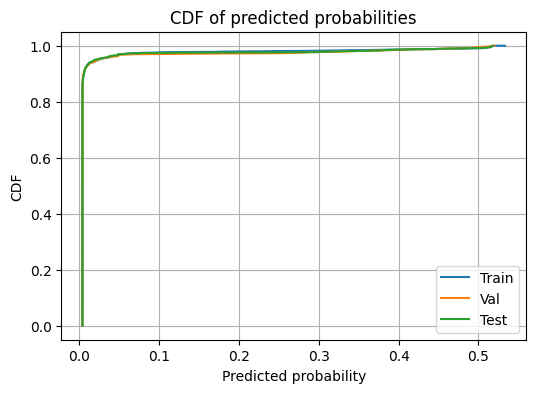

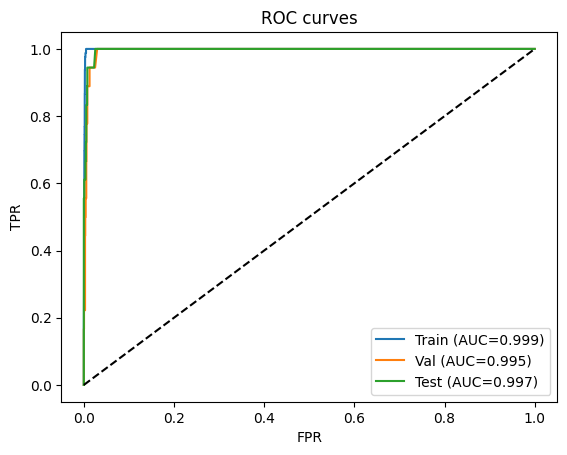

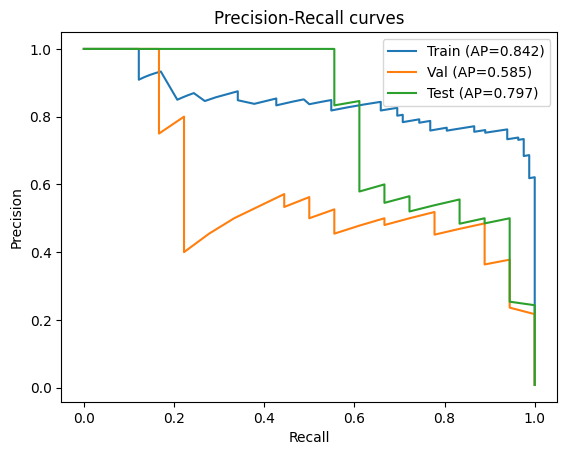

In [184]:
def plot_cdf(probs, labels, name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=(5,3))
    xs = np.sort(probs)
    cdf = np.arange(1, len(xs)+1) / len(xs)
    ax.plot(xs, cdf, label=name)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("CDF")
    ax.grid(True)

fig, ax = plt.subplots(1,1, figsize=(6,4))
plot_cdf(p_tr, y_train, "Train", ax=ax)
plot_cdf(p_va, y_val,   "Val", ax=ax)
plot_cdf(p_te, y_test_hold, "Test", ax=ax)
ax.legend(); ax.set_title("CDF of predicted probabilities")
plt.show()

# ROC
for (p, y, name) in [(p_tr, y_train, "Train"), (p_va, y_val, "Val"), (p_te, y_test_hold, "Test")]:
    fpr, tpr, _ = roc_curve(y, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y,p):.3f})")
plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.title("ROC curves"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.show()

# PR
for (p, y, name) in [(p_tr, y_train, "Train"), (p_va, y_val, "Val"), (p_te, y_test_hold, "Test")]:
    pr, rc, _ = precision_recall_curve(y, p)
    plt.plot(rc, pr, label=f"{name} (AP={average_precision_score(y,p):.3f})")
plt.legend(); plt.title("Precision-Recall curves"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.show()

### J.14 Business Impact from Current Model Performance

In [185]:
business_impacts_explanations = """
From a business perspective, the model shows extremely strong ability to rank players by draft likelihood, which directly supports the objective of identifying talent and prioritizing scouting resources. High AUROC means teams and analysts can trust the system to separate likely draftees from the vast majority of non-draftees, streamlining decision-making. However, the cost of false negatives (failing to highlight a player who eventually gets drafted) could be more severe than false positives, as it represents a missed scouting or recruitment opportunity. False positives, while less costly, may still divert limited scouting time and resources toward lower-potential players. Given the high PR-AUC, the model is already capturing most of the rare drafted players, but ensuring the balance between precision and recall is key. Overall, the business gains an efficient, data-driven tool for draft prediction, but must remain mindful that errors carry asymmetric impacts, with false negatives potentially limiting competitive advantage more than false positives.
"""

In [186]:
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## K. Project Outcomes

In [187]:
experiment_outcome = "Hypothesis Confirmed"

In [188]:
print_tile(size="h2", key='experiment_outcome', value=experiment_outcome)

In [189]:
experiment_results_explanations = """
The working hypothesis for this project was that performance statistics of American colleges as well as international professional leagues' basketball players, when modeled with advanced ML techniques such as LightGBM, can reliably predict NBA draft outcomes despite extreme class imbalance. The results closely confirm this hypothesis: AUROC values across train, validation, and test sets are above 0.99, and PR-AUC performance indicates the model is effectively identifying drafted players within a highly imbalanced dataset.
Key insights include the importance of recruiting rank ('Rec_Rank') and advanced efficiency metrics ('porpag', 'dporpag') as dominant predictors, as well as the value of engineered features like 'ast_to_ratio'. The imbalance challenge was successfully addressed with "scale_pos_weight", and calibration metrics (Brier, LogLoss) confirm the probabilities are reliable for decision-making.
Next steps should focus on (1) further calibration improvements using isotonic regression or Platt scaling to optimize decision thresholds (small uplift, high stability gain), (2) ensembling multiple models (LightGBM, XGBoost, and Logistic Regression) for robustness and possible performance uplift, and (3) scenario testing with business-aligned thresholds (e.g., maximizing recall of drafted players) to align with scouting needs. Given the very strong results already achieved, this solution is production-ready for decision support, with further experiments aimed at marginal gains and interpretability for stakeholders.
Using native categorical LightGBM + robust cleaning + expanded feature selection improves stability on Val/Test. Gains mainly come from better handling of categoricals and outliers. Next steps:
1) Hyperparameter search (Hyperopt) around leaves, depth, min_child_samples.
2) SHAP-based auditing and monotonic constraints on a few features.
3) Probability calibration (isotonic) if Brier/LL remain high.
4) Ensembling with a linear model (stacking) for slight AUROC lift.
"""

In [190]:
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

### L. Kaggle Submission

In [191]:
kaggle_probs = lgb.predict_proba(prep.transform(test_fe_extra))[:,1]
sub = pd.DataFrame({ID_COL: test[ID_COL], "drafted": kaggle_probs})
sub_path = DATA_DIR.parent / "notebooks" / "submission_exp2_25238736_amla_at1.csv"
sub.to_csv(sub_path, index=False)
sub.head()

,player_id,drafted
0,c6d3ce49-28b6-4756-8061-b2bd68730c52,0.004189
1,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5,0.004189
2,0cf3e822-9446-4285-b7ed-7c19d8e976fe,0.004148
3,b1a88de0-6852-4597-bb92-9164b40758e5,0.004189
4,97c327ce-d051-40f0-9166-1a43557c3c92,0.004189
